In [ ]:
# prompt: 請讀取winequality-red.csv，數據是用逗號進行分隔

import pandas as pd

# Assuming the file is in the current working directory
try:
    df = pd.read_csv('winequality-red.csv', delimiter=',')
    # print(df.head())  # Print the first few rows to verify
except FileNotFoundError: #提醒使用者程式錯誤的地方，避免其慌張
    print("Error: winequality-red.csv not found. Please ensure the file exists in the current directory or provide the correct path.")
except pd.errors.ParserError:
    print("Error: Could not parse the CSV file. Please check the file format and delimiter.")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
# prompt: 請移除df的空值（僅顯示此動作的程式碼）

df = df.dropna()


In [1]:
# prompt: 產生df的敘述其統計結果

# Generate descriptive statistics for the DataFrame
df_description = df.describe()
df_description


NameError: name 'df' is not defined

For n_clusters = 2 The average silhouette_score is : 0.6035626051885711
For n_clusters = 3 The average silhouette_score is : 0.5183407230721446
For n_clusters = 4 The average silhouette_score is : 0.4837711101297133
For n_clusters = 5 The average silhouette_score is : 0.43847824651181827
For n_clusters = 6 The average silhouette_score is : 0.39579565308238346
For n_clusters = 7 The average silhouette_score is : 0.3737996245400908
For n_clusters = 8 The average silhouette_score is : 0.3774620700442961
For n_clusters = 9 The average silhouette_score is : 0.3812260631235836
For n_clusters = 10 The average silhouette_score is : 0.3781708858013614
The best k is: 2


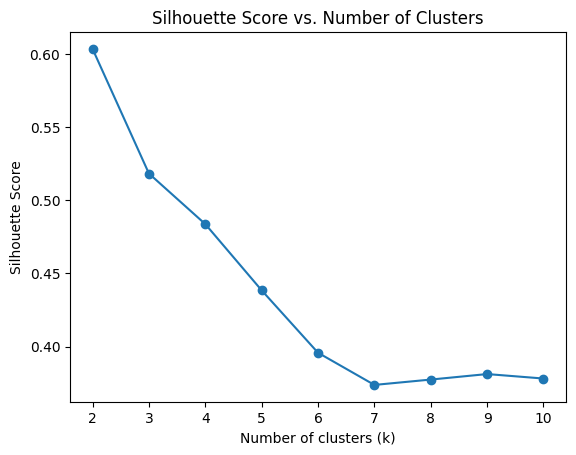

In [12]:
# prompt:  請針對df進行kmeans，并且用輪廓係數得到最佳的分組組數要print出來，繪製輪廓係數與k值來得到曲綫圖（僅呈現此動作的程式碼即可）

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assuming 'df' is your DataFrame and is already preprocessed

range_n_clusters = range(2, 11) #k from 2 to 10
silhouette_avg_list = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0) #random_state for reproducibility
    cluster_labels = kmeans.fit_predict(df)
    silhouette_avg = silhouette_score(df, cluster_labels)
    silhouette_avg_list.append(silhouette_avg)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

# Find the best k
best_k = range_n_clusters[silhouette_avg_list.index(max(silhouette_avg_list))]
print(f"The best k is: {best_k}")


# Plot the silhouette scores
plt.plot(range_n_clusters, silhouette_avg_list, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()


In [14]:
# prompt: 以k=2，進行kmeans分群，將分群結果（每一點的數值以及所屬的分群）匯出成excel，檔名為renwine_keans_result(僅呈現此動作的·程式碼)

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(df)

# Create a new DataFrame with cluster labels
df_with_clusters = df.copy()
df_with_clusters['cluster'] = cluster_labels

# Export the DataFrame to an Excel file
df_with_clusters.to_excel('renwine_keans_result.xlsx', index=False)
